# Random Forest

## 1. O que é uma Random Forest?

De acordo com a Geekforge, uma Random Forest é um algoritmo de aprendizagem automática que utiliza várias árvores de decisão para fazer melhores previsões. Cada árvore analisa diferentes partes aleatórias dos dados e os seus resultados são combinados através de votação, no caso da classificação, ou de cálculo da média, no caso da regressão, o que a torna uma técnica de aprendizagem em conjunto. Isto ajuda a melhorar a precisão e a reduzir os erros.



## 2. Funcionamento de uma Random Forest

- Criação de várias árvores de decisão: O algoritmo cria várias árvores de decisão, cada uma utilizando uma parte aleatória dos dados. Assim, cada árvore é ligeiramente diferente;
- Seleção aleatória de características: Ao construir cada árvore, o algoritmo não analisa todas as características de uma só vez. Seleciona algumas aleatoriamente para decidir como dividir os dados. Isto ajuda a garantir que as árvores se mantêm diferentes umas das outras;
- Cada árvore faz uma previsão: Cada árvore dá a sua própria resposta ou previsão com base no que aprendeu com a sua parte dos dados;
- Combinar as previsões: Para a classificação, escolhemos uma categoria, pois a resposta final é aquela em que a maioria das árvores concorda, ou seja, votação por maioria; e para a regressão, prevemos um número, pois a resposta final é a média de todas as previsões das árvores;
- Por que funciona bem: A utilização de dados e características aleatórias para cada árvore ajuda a evitar o sobreajuste e torna a previsão global mais precisa e fiável.


## 3. Características de uma Random Forest

- Lida com dados em falta: funciona mesmo que faltem alguns dados, pelo que nem sempre é necessário preencher as lacunas manualmente;
- Mostra a importância das características: indica quais as características mais úteis para fazer previsões, o que ajuda a compreender melhor os seus dados;
- Funciona bem com dados grandes e complexos: consegue lidar com grandes conjuntos de dados com muitas características sem abrandar ou perder precisão;
- Utilizado para diferentes tarefas: pode ser utilizado tanto para classificação, como para prever tipos ou rótulos, como para regressão, como prever números ou quantidades.

## 4. Pressupostos de uma Random Forest

- Cada árvore toma as suas próprias decisões: cada árvore da floresta faz as suas próprias previsões sem depender das outras;
- São utilizadas partes aleatórias dos dados: cada árvore é construída utilizando amostras e características aleatórias para reduzir os erros;
- É necessária uma quantidade suficiente de dados: dados suficientes garantem que as árvores sejam diferentes e aprendam padrões únicos e variados;
- Previsões diferentes melhoram a precisão: a combinação das previsões de diferentes árvores conduz a um resultado final mais preciso.

## 5. Implementação de uma Random Forest para Classificação



Neste exemplo, foi usada a Iris Dataset, um conjunto de dados clássico que contém informações sobre as características de diferentes tipos de flores. O objetivo é treinar um modelo de Random Forest para classificar as flores com base nas suas características. Foi utilizado o `RandomForestClassifier` da biblioteca `sklearn.ensemble` para criar o modelo, e o desempenho do modelo foi avaliado usando métricas como a precisão e o relatório de classificação.

A precisão foi obtida através da função `accuracy_score`, que calcula a proporção de previsões corretas em relação ao total de amostras. O relatório de classificação foi gerado usando a função `classification_report`, que fornece uma visão detalhada do desempenho do modelo para cada classe, incluindo as métricas mencionadas anteriormente.

No relatório de classificação, as métricas de precisão, recall e F1-score são apresentadas para cada classe, o que ajuda a entender melhor o desempenho do modelo em cada categoria de flores. Onde a recall indica a capacidade do modelo de identificar corretamente as amostras positivas, e o F1-score é a média harmónica entre a precisão e a recall, fornecendo uma medida equilibrada do desempenho do modelo. O support indica o número de amostras reais em cada classe, o que é importante para avaliar a performance do modelo em classes desbalanceadas. 

Para obter uma amostra real vs prevista, foi selecionada a primeira amostra do conjunto de teste, e a previsão do modelo para essa amostra foi comparada com a classe real correspondente. 

In [1]:
import pandas as pd # Importa a biblioteca pandas para manipulação de dados
from sklearn.model_selection import train_test_split # Importa a função train_test_split para dividir os dados em conjuntos de treino e teste
from sklearn.ensemble import RandomForestClassifier # Importa o classificador Random Forest da biblioteca sklearn.ensemble
from sklearn.preprocessing import LabelEncoder # Importa o LabelEncoder para codificar as variáveis categóricas
from sklearn.metrics import accuracy_score, classification_report # Importa as métricas de avaliação do modelo

df = pd.read_csv('IrisDataset.csv') # Lê o arquivo CSV contendo o dataset Iris e armazena num DataFrame do pandas
X = df[['sepal length (cm)','sepal width (cm)','petal length (cm)','petal width (cm)']] # Seleciona as colunas de características (features) do dataset para usar como variáveis independentes
y = df['species'] # Seleciona a coluna 'species' do dataset para usar como variável dependente (target)

le = LabelEncoder() # Cria uma instância do LabelEncoder para codificar as classes da variável dependente
y_enc = le.fit_transform(y) # Aplica o LabelEncoder à variável dependente 'y' para transformar as classes em valores numéricos, armazenando o resultado em 'y_enc'

""" Divide os dados em conjuntos de treino e teste usando a função train_test_split. 
O conjunto de teste representa 30% dos dados, e a divisão é estratificada para manter a proporção das classes em ambos os conjuntos. """
X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.3, random_state=42, stratify=y_enc) 

clf = RandomForestClassifier(n_estimators=100, random_state=42) # Cria uma instância do classificador Random Forest com 100 árvores (n_estimators) e uma semente aleatória (random_state) para garantir a reprodutibilidade dos resultados
clf.fit(X_train, y_train) # Treina o modelo de Random Forest usando os dados de treino (X_train e y_train)

y_pred = clf.predict(X_test) # Usa o modelo treinado para fazer previsões sobre os dados de teste (X_test), armazenando as previsões em 'y_pred'
acc = accuracy_score(y_test, y_pred) # Calcula a precisão do modelo comparando as previsões (y_pred) com as classes reais (y_test) usando a função accuracy_score, armazenando o resultado em 'acc'
print(f'Precisão: {acc:.2f}') 
print('\nRelatório de Classificação:\n', classification_report(y_test, y_pred, target_names=le.classes_, digits=2)) 

sample = X_test.iloc[[0]] # Seleciona a primeira amostra do conjunto de teste (X_test) usando iloc para obter a linha correspondente, armazenando a amostra selecionada em 'sample'
pred_class = clf.predict(sample) # Usa o modelo treinado para prever a classe da amostra selecionada, armazenando a previsão em 'pred_class'
true_class = le.inverse_transform([y_test[0]]) # Usa o LabelEncoder para transformar a classe real da amostra selecionada (y_test[0]) de volta para o formato original (string) usando inverse_transform, armazenando o resultado em 'true_class'
print('Amostra:', X_test.iloc[0].values)
print('Classe verdadeira:', true_class[0])
print('Classe prevista:', le.inverse_transform(pred_class)[0])

Precisão: 0.89

Relatório de Classificação:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.78      0.93      0.85        15
   virginica       0.92      0.73      0.81        15

    accuracy                           0.89        45
   macro avg       0.90      0.89      0.89        45
weighted avg       0.90      0.89      0.89        45

Amostra: [7.3 2.9 6.3 1.8]
Classe verdadeira: virginica
Classe prevista: virginica


## 6. Implementação de uma Random Forest para Regressão

Aqui, foi utilizada mais uma vez a Iris Dataset, mas desta vez o objetivo é prever a largura da sépala com base nas outras características. Foi utilizado o `RandomForestRegressor` da biblioteca `sklearn.ensemble` para criar o modelo, e o desempenho do modelo foi avaliado usando métricas como o erro médio absoluto (MAE) e o erro quadrático médio (MSE).
Essas métricas ajudam a entender o quão bem o modelo está a prever os valores reais, onde o MAE mede a média dos erros absolutos entre as previsões e os valores reais, e o MSE mede a média dos erros quadráticos, penalizando mais os erros maiores.
O valor previsto para a largura da sépala é comparado com o valor atual para avaliar a precisão da previsão do modelo.

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('IrisDataset.csv')
X = df[['sepal width (cm)','petal length (cm)','petal width (cm)','species']].copy()
le = LabelEncoder()
X['species'] = le.fit_transform(X['species'])
y = df['sepal length (cm)']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) # Divide os dados em conjuntos de treino e teste, reservando 30% dos dados para teste e usando uma semente aleatória para garantir a reprodutibilidade

reg = RandomForestRegressor(n_estimators=100, random_state=42) # Cria uma instância do regressor Random Forest com 100 árvores (n_estimators) e uma semente aleatória (random_state) para garantir a reprodutibilidade dos resultados
reg.fit(X_train, y_train) # Treina o modelo de Random Forest para regressão usando os dados de treino (X_train e y_train)

y_pred = reg.predict(X_test) # Usa o modelo treinado para fazer previsões sobre os dados de teste (X_test), armazenando as previsões em 'y_pred'

pred_first = float(y_pred[0]) # Converte a primeira previsão (y_pred[0]) para um valor float e armazena em 'pred_first' para facilitar a comparação com o valor real correspondente
actual_first = float(y_test.values[0]) # Converte o primeiro valor real do conjunto de teste (y_test.values[0]) para um valor float e armazena em 'actual_first' para facilitar a comparação com a previsão correspondente
print('Predicted Value:', f'{pred_first:.2f}')
print('Actual Value:', f'{actual_first:.2f}')

mse = mean_squared_error(y_test, y_pred) # Calcula o erro quadrático médio (MSE) entre as previsões (y_pred) e os valores reais (y_test) usando a função mean_squared_error, armazenando o resultado em 'mse'
r2 = r2_score(y_test, y_pred) # Calcula o coeficiente de determinação (R²) entre as previsões (y_pred) e os valores reais (y_test) usando a função r2_score, armazenando o resultado em 'r2'
print('Mean Squared Error:', f'{mse:.2f}')
print('R-squared Score:', f'{r2:.2f}')


Predicted Value: 6.16
Actual Value: 6.10
Mean Squared Error: 0.08
R-squared Score: 0.88


## 7. Vantagens e Limitações de uma Random Forest
### Vantagens 

- A Random Forest fornece previsões muito precisas, mesmo com conjuntos de dados de grande dimensão;
- A Random Forest consegue lidar bem com dados em falta sem comprometer a precisão;
- Não requer normalização nem padronização do conjunto de dados;
- Ao combinarmos várias árvores de decisão, reduz-se o risco de sobreajuste do modelo.

### Limitações

- Pode ser computacionalmente dispendiosa, especialmente com um grande número de árvores;
- É mais difícil interpretar o modelo em comparação com modelos mais simples, como as árvores de decisão.


## 8. Conclusão

A Random Forest é um algoritmo de aprendizagem automática poderoso e versátil que pode ser utilizado para tarefas de classificação e regressão. A sua capacidade de lidar com dados em falta, fornecer informações sobre a importância das características e evitar o sobreajuste torna-a uma escolha popular para muitos problemas de aprendizagem automática. No entanto, é importante considerar as suas limitações, como a necessidade de recursos computacionais e a dificuldade de interpretação, ao decidir se é a melhor opção para um determinado problema. 
Como visto no exemplo de classificação, a Random Forest pode alcançar uma alta precisão e fornecer um relatório detalhado do desempenho do modelo para cada classe. No exemplo de regressão, a Random Forest também demonstrou ser eficaz na previsão de valores numéricos, embora seja importante avaliar as métricas de erro para entender a qualidade das previsões.

# Titanic

## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

d_train = pd.read_csv("../Datasets/titanic_train.csv")
d_test = pd.read_csv("../Datasets/titanic_test.csv")
d_pred = pd.read_csv("../Datasets/titanic_test_results.csv")

d_train.columns, d_test.columns, d_pred.columns

(Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
        'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
       dtype='object'),
 Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
        'Ticket', 'Fare', 'Cabin', 'Embarked'],
       dtype='object'),
 Index(['PassengerId', 'Survived'], dtype='object'))

In [3]:
df = d_train

## EDA

In [4]:
df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

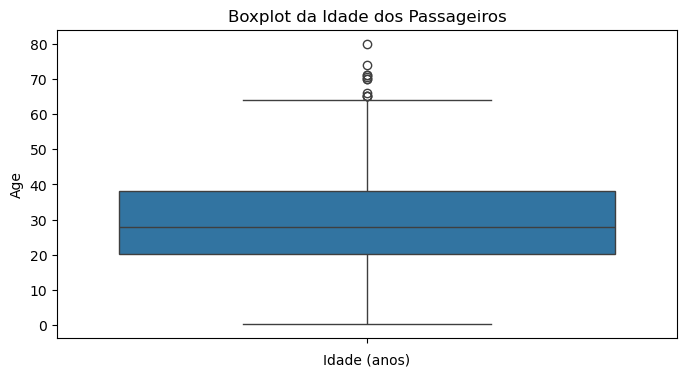

In [12]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df["Age"])
plt.title("Boxplot da Idade dos Passageiros")
plt.xlabel("Idade (anos)")
plt.show()

Text(0.5, 1.0, 'Histograma da Idade dos Passageiros')

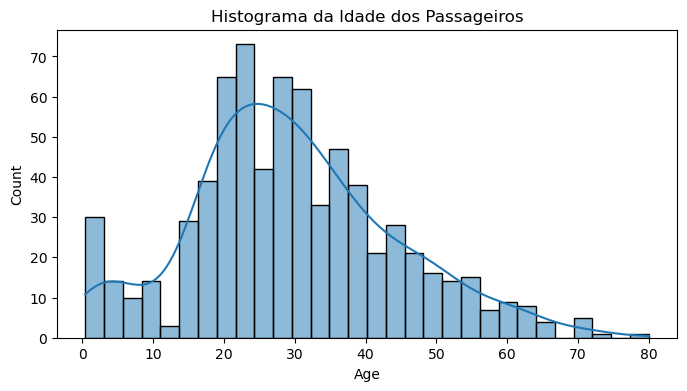

In [16]:
plt.figure(figsize=(8,4))
sns.histplot(data=df["Age"], bins=30, kde=True)
plt.title("Histograma da Idade dos Passageiros")

In [24]:
df[df["Fare"] > 500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C
679,680,1,1,"Cardeza, Mr. Thomas Drake Martinez",male,36.0,0,1,PC 17755,512.3292,B51 B53 B55,C
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C


In [18]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [20]:
df["Embarked"].unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [21]:
df["Embarked"].value_counts()

Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [22]:
df[df["Survived"]==1].Embarked.value_counts()   

Embarked
S    217
C     93
Q     30
Name: count, dtype: int64

## Preprocessing

In [28]:
df=df.drop(["Name","Cabin", "PassengerId"], axis=1)
d_test=d_test.drop(["Name","Cabin", "PassengerId"], axis=1)

In [29]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,S
887,1,1,female,19.0,0,0,112053,30.0000,S
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,male,26.0,0,0,111369,30.0000,C


In [31]:
df = df.dropna(subset=["Embarked"])
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,S
887,1,1,female,19.0,0,0,112053,30.0000,S
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,male,26.0,0,0,111369,30.0000,C


In [ ]:
df[{'Pclass', 'Age', 'Fare'}].groupby('Pclass').mean()


In [33]:
df[df.Fare.isnull()]

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked


In [34]:
df.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Ticket        0
Fare          0
Embarked      0
dtype: int64

In [35]:
df.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Ticket       object
Fare        float64
Embarked     object
dtype: object

In [38]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

In [40]:
columns_to_encode = ['Sex', 'Embarked']
encoded_data = encoder.fit_transform(df[columns_to_encode])
encoder.categories_

[array(['female', 'male'], dtype=object), array(['C', 'Q', 'S'], dtype=object)]

In [42]:
encoded_test_data = encoder.transform(d_test[columns_to_encode])
encoded_test_data

array([[0., 1., 0., 1., 0.],
       [1., 0., 0., 0., 1.],
       [0., 1., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 1.],
       [0., 1., 0., 0., 1.],
       [0., 1., 1., 0., 0.]], shape=(418, 5))

In [45]:
future_names = encoder.get_feature_names_out(columns_to_encode)
future_names

array(['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype=object)

In [49]:
encoded_df = pd.DataFrame(encoded_data, columns=future_names)
encoded_df

,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,0.0,1.0,0.0,0.0,1.0
1,1.0,0.0,1.0,0.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...
884,0.0,1.0,0.0,0.0,1.0
885,1.0,0.0,0.0,0.0,1.0
886,1.0,0.0,0.0,0.0,1.0
887,0.0,1.0,1.0,0.0,0.0


In [ ]:
df

,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,0,3,male,22.0,1,0,A/5 21171,7.2500,S
1,1,1,female,38.0,1,0,PC 17599,71.2833,C
2,1,3,female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,1,1,female,35.0,1,0,113803,53.1000,S
4,0,3,male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,211536,13.0000,S
887,1,1,female,19.0,0,0,112053,30.0000,S
888,0,3,female,NaN,1,2,W./C. 6607,23.4500,S
889,1,1,male,26.0,0,0,111369,30.0000,C


## Train

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score

In [54]:
X_train = df.drop("Survived", axis=1)
Y_train = df["Survived"]

X_test = d_test
Y_test = d_pred["Survived"]